**Cell 1 — Imports and configuration**

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t as t_dist

OUTPUT_DIR = os.getcwd()

RHO_RANGE = (-0.999, 0.999)
DOF_RANGE = (1, 100)
N_POINTS = 100

**Cell 2 — Grid on correlation and degrees of freedom**

In [2]:
rho = np.linspace(*RHO_RANGE, N_POINTS)
dof = np.linspace(*DOF_RANGE, N_POINTS)
RHO, DOF = np.meshgrid(rho, dof)

**Cell 3 — Upper tail dependence function**

In [3]:
def t_copula_tail_dependence(rho, dof):
    # lambda_U = 2 * T_{dof+1}(-sqrt((dof+1)(1-rho)/(1+rho)))
    return 2 * t_dist.cdf(-np.sqrt((dof + 1) * (1 - rho) / (1 + rho)), dof + 1)

lambda_U = t_copula_tail_dependence(RHO, DOF)

**Cell 4 — 3D surface plot**

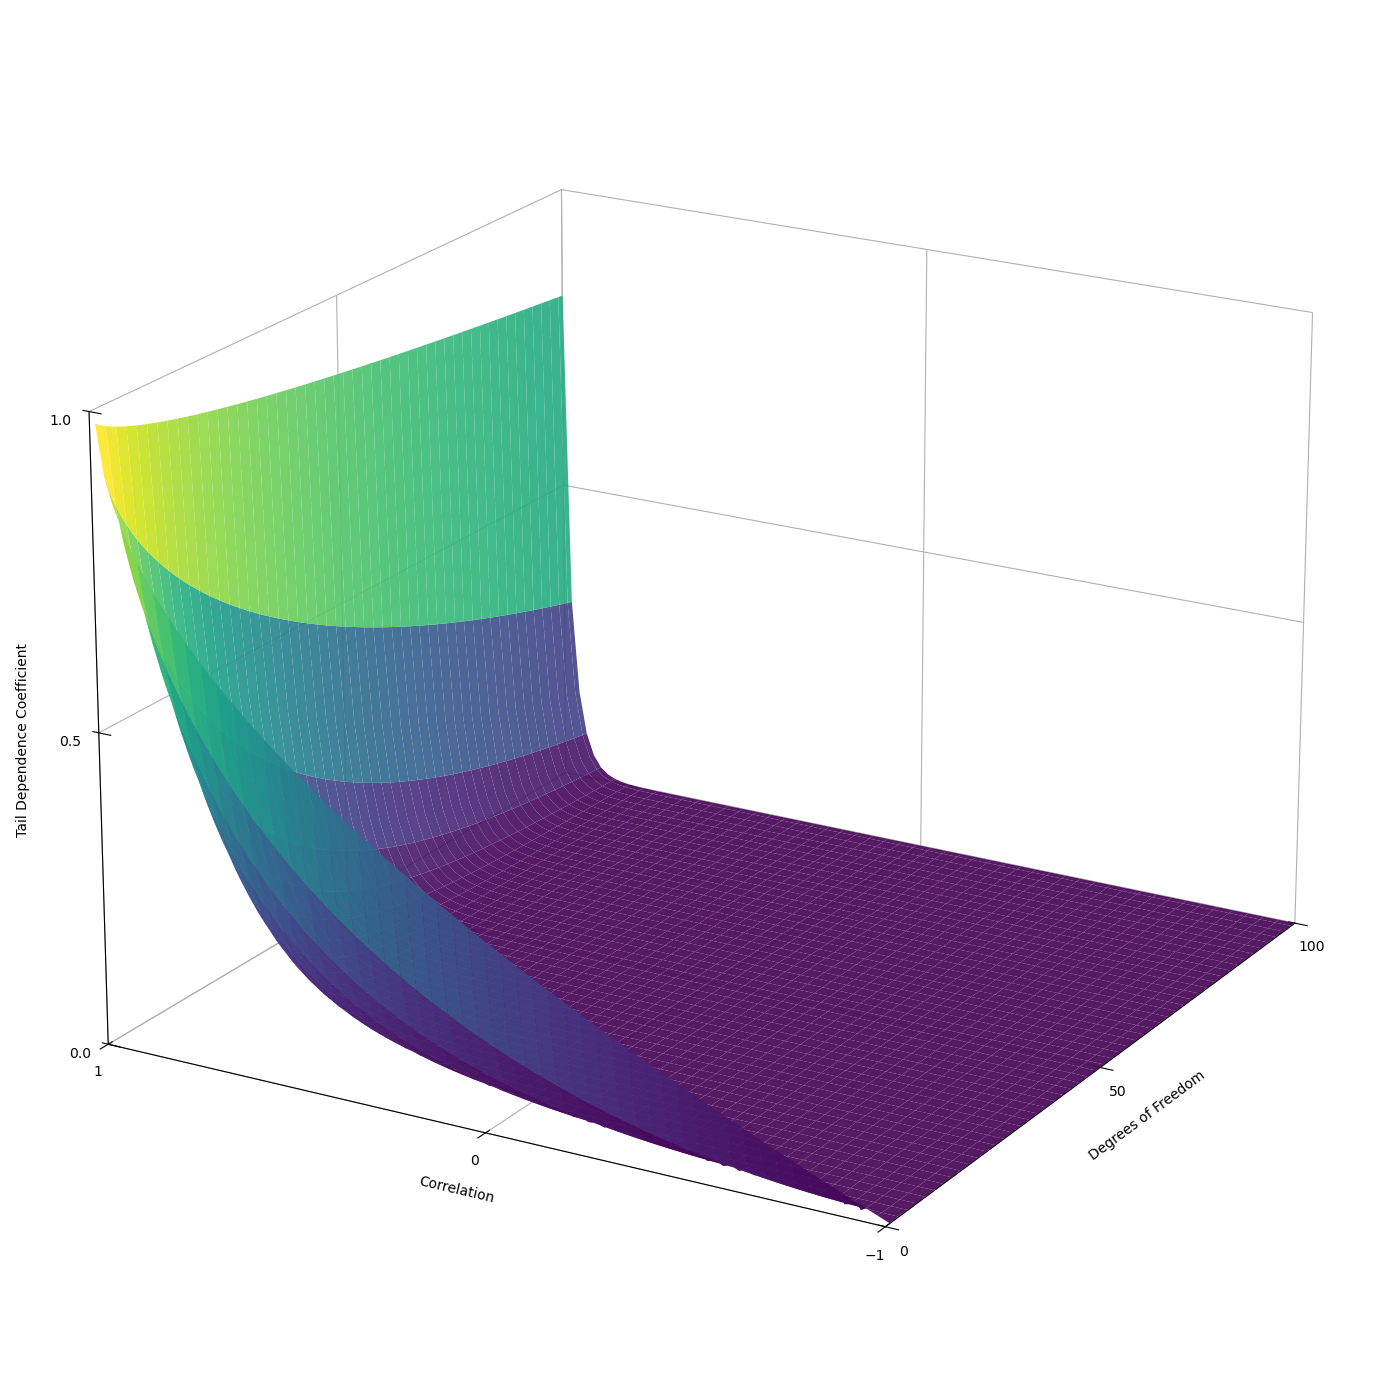

In [5]:
fig = plt.figure(figsize=(14, 16))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(RHO, DOF, lambda_U, cmap="viridis", edgecolor="none", alpha=0.9)

ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor("white")
ax.yaxis.pane.set_edgecolor("white")
ax.zaxis.pane.set_edgecolor("white")

ax.set_xlabel("Correlation", labelpad=10)
ax.set_ylabel("Degrees of Freedom", labelpad=10)

ax.set_xlim(1, -1)
ax.set_ylim(0, 100)
ax.set_zlim(0, 1)
ax.set_xticks([1, 0, -1])
ax.set_yticks([0, 50, 100])
ax.set_zticks([0, 0.5, 1])
ax.view_init(elev=20, azim=-60)

# z-axis: left wall + vertical label
ax.zaxis._axinfo['juggled'] = (1, 2, 0)
ax.zaxis.set_rotate_label(False)  # disable auto-rotation
ax.set_zlabel("Tail Dependence Coefficient", rotation=90, labelpad=10)  # force vertical

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "tdc_t_copula.png"),
            dpi=200, transparent=True, bbox_inches="tight")
plt.show()